Importing the Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Importing Metrics for Classification technique

In [2]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

Importing Required Scales

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import  RandomizedSearchCV, train_test_split

Importing Model Building Algorithms

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

Importing DataSet

In [5]:
heart_data = pd.read_csv(r"C:\Users\tanma\OneDrive\Desktop\KO\Study Materials\ML AI\csv files\heart_disease_data.csv")

In [6]:
heart_data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


Data Processing and Understanding Our Dataset

In [7]:
heart_data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [8]:
heart_data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [9]:
heart_data.shape

(303, 14)

In [10]:
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [11]:
heart_data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [12]:
heart_data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [13]:
info = ["age",
        "1: male, 0: female",
        "chest pain type, 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic",
        "resting blood pressure",
        " serum cholestoral in mg/dl",
        "fasting blood sugar > 120 mg/dl",
        "resting electrocardiographic results (values 0,1,2)",
        " maximum heart rate achieved",
        "exercise induced angina",
        "oldpeak = ST depression induced by exercise relative to rest",
        "the slope of the peak exercise ST segment",
        "number of major vessels (0-3) colored by flourosopy",
        "thal: 3 = normal; 6 = fixed defect; 7 = reversable defect"
       ]



for i in range(len(info)):
    print(heart_data.columns[i]+":\t\t"+info[i])

age:		age
sex:		1: male, 0: female
cp:		chest pain type, 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic
trestbps:		resting blood pressure
chol:		 serum cholestoral in mg/dl
fbs:		fasting blood sugar > 120 mg/dl
restecg:		resting electrocardiographic results (values 0,1,2)
thalach:		 maximum heart rate achieved
exang:		exercise induced angina
oldpeak:		oldpeak = ST depression induced by exercise relative to rest
slope:		the slope of the peak exercise ST segment
ca:		number of major vessels (0-3) colored by flourosopy
thal:		thal: 3 = normal; 6 = fixed defect; 7 = reversable defect


In [14]:
heart_data['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [15]:
heart_data["target"].describe()

count    303.000000
mean       0.544554
std        0.498835
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        1.000000
Name: target, dtype: float64

Exploratory Data Analysis

In [16]:
print(heart_data.corr()["target"].abs().sort_values(ascending=False))


target      1.000000
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


In [17]:
print(heart_data.corr()["target"].abs().sort_values(ascending=False))

target      1.000000
exang       0.436757
cp          0.433798
oldpeak     0.430696
thalach     0.421741
ca          0.391724
slope       0.345877
thal        0.344029
sex         0.280937
age         0.225439
trestbps    0.144931
restecg     0.137230
chol        0.085239
fbs         0.028046
Name: target, dtype: float64


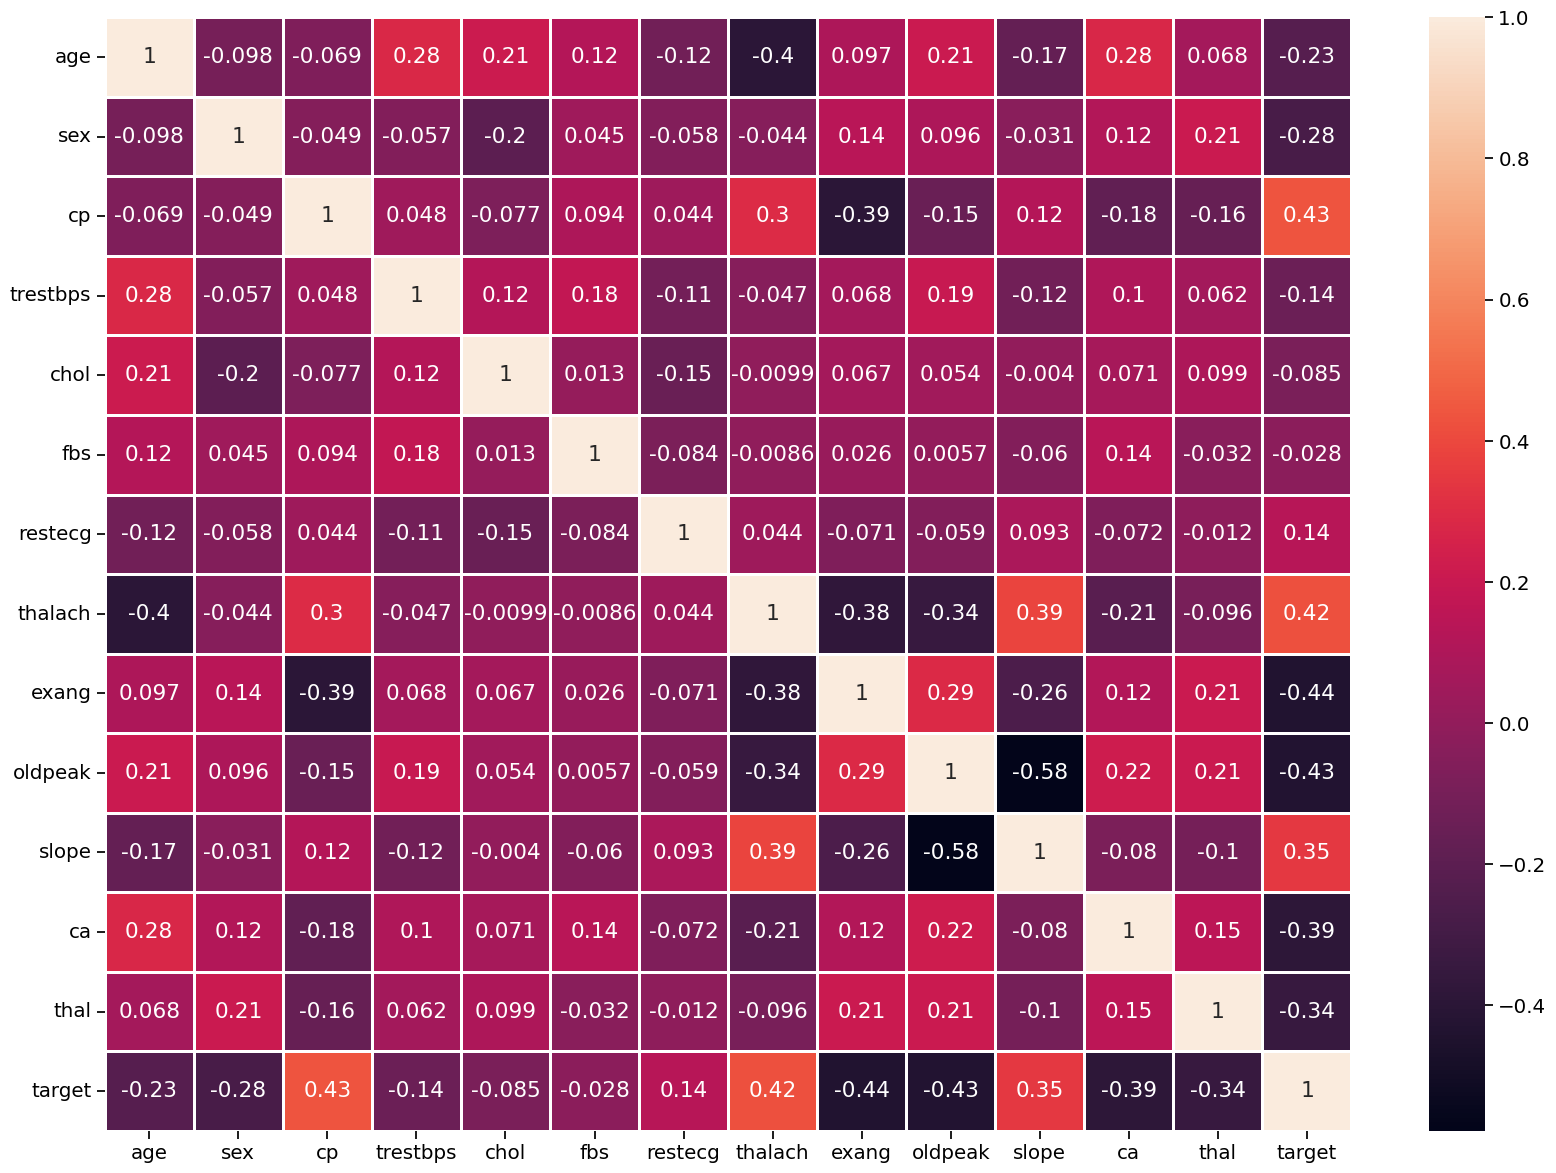

In [18]:
plt.figure(figsize=(17,12))
sns.set_context('notebook',font_scale = 1.3)
sns.heatmap(heart_data.corr(),annot=True,linewidth =2)
plt.tight_layout()

In [19]:
print('Min Age :',min(heart_data.age))
print('Max Age :',max(heart_data.age))
print('Mean Age :',heart_data.age.mean())

Min Age : 29
Max Age : 77
Mean Age : 54.366336633663366


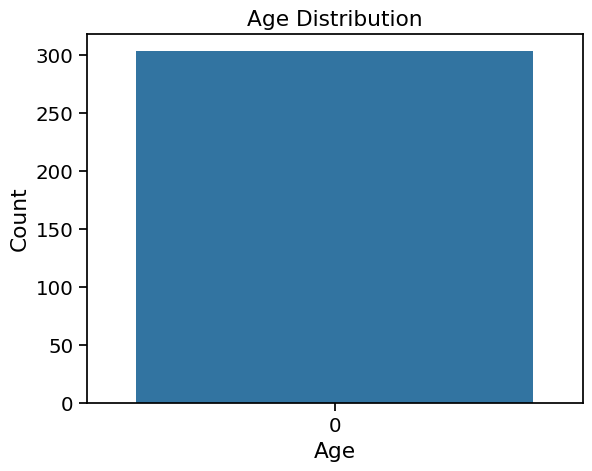

In [20]:
sns.countplot(heart_data.age) 
plt.xlabel('Age') 
plt.ylabel('Count') 
plt.title('Age Distribution')
plt.show()

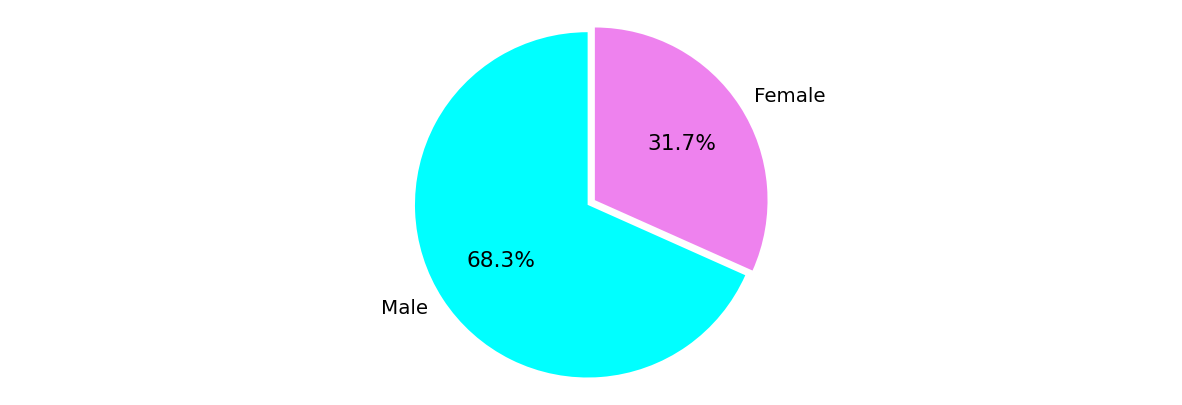

In [21]:
male = len(heart_data[heart_data['sex'] == 1]) # Assign variable 'male' as the length of '1' in the feature 'sex' 
female = len(heart_data[heart_data['sex'] == 0]) # Assign variable 'female' as the length of '0' in the feature'sex'
labels = 'Male','Female'
sizes = [male, female]
colors = ['cyan', 'violet']
explode = (0, 0.05)  


plt.figure(figsize=(15,5)) # Size of the figure

plt.pie(sizes, explode=explode, labels=labels, colors=colors,
autopct='%1.1f%%', shadow=False, startangle=90)
 
plt.axis('equal') # Ensure that the pie chart is drawn as a circle
plt.show()

Young People: 16 
Middle Age People: 128 
Elderly People: 151


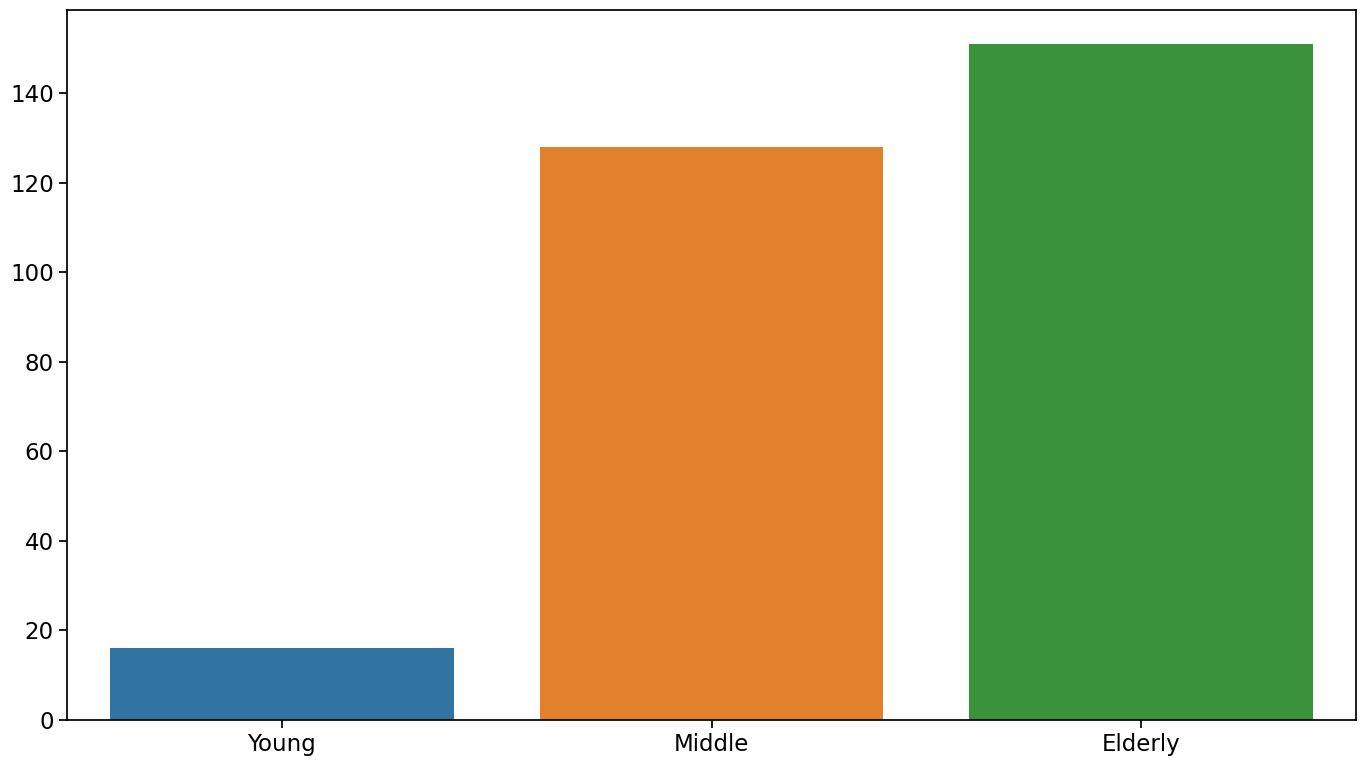

In [22]:
Young = heart_data[(heart_data.age>=29)&(heart_data.age<40)]
Middle = heart_data[(heart_data.age>=40)&(heart_data.age<55)]
Elder = heart_data[(heart_data.age>55)]

print("Young People:",len(Young),"\nMiddle Age People:",len(Middle),"\nElderly People:",len(Elder))

plt.figure(figsize=(14,8))
sns.set_context('notebook',font_scale = 1.5)
sns.barplot(x=['Young','Middle','Elderly'],y=[len(Young),len(Middle),len(Elder)])
plt.tight_layout()

target
1    165
0    138
Name: count, dtype: int64


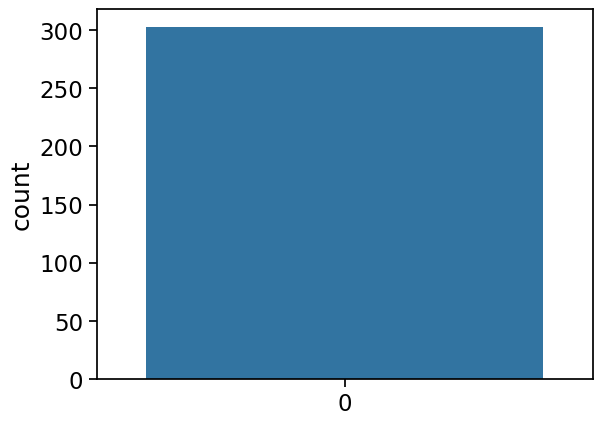

In [23]:
y = heart_data["target"]
sns.countplot(y)
target_temp = heart_data.target.value_counts()
print(target_temp)

sex
1    207
0     96
Name: count, dtype: int64


<Axes: xlabel='sex', ylabel='target'>

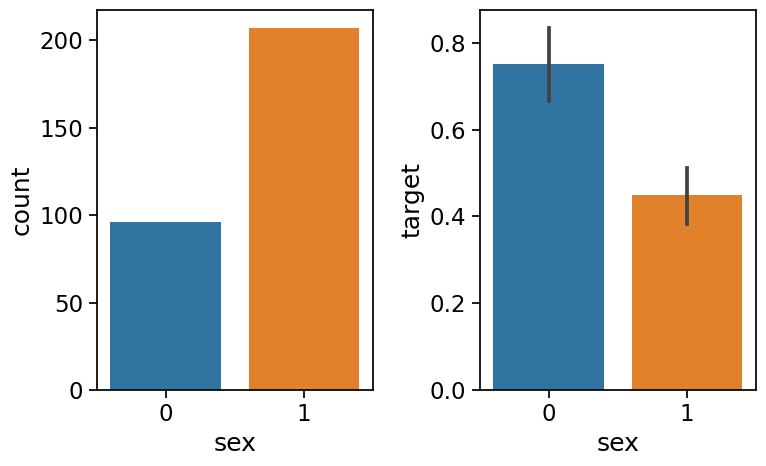

In [24]:
plt.rcParams["figure.figsize"] = [8.00, 5.00]
plt.rcParams["figure.autolayout"] = True

fig, axes = plt.subplots(1, 2)

temp = heart_data.sex.value_counts()
print(temp)

sns.countplot(data=heart_data, x='sex', ax=axes[0])
sns.barplot(data=heart_data, x='sex', y=y, ax=axes[1])

cp
0    143
2     87
1     50
3     23
Name: count, dtype: int64


<Axes: xlabel='cp', ylabel='target'>

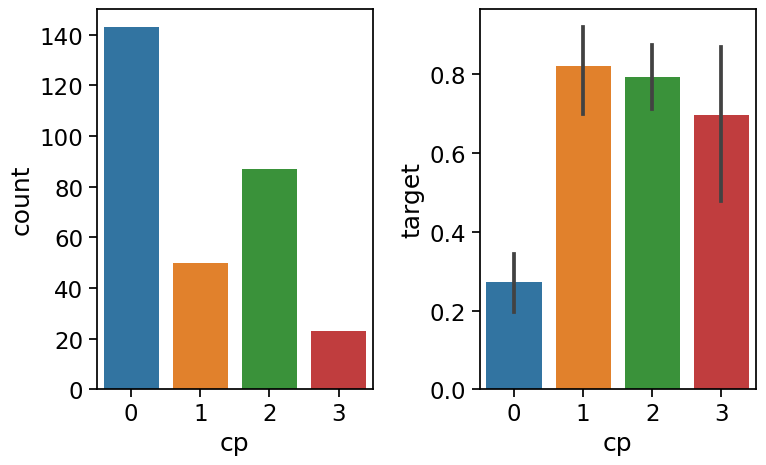

In [25]:
fig, axes = plt.subplots(1, 2)

temp = heart_data.cp.value_counts()
print(temp)

sns.countplot(data=heart_data, x='cp', ax=axes[0])
sns.barplot(data=heart_data, x='cp', y=y, ax=axes[1])

fbs
0    258
1     45
Name: count, dtype: int64


<Axes: xlabel='fbs', ylabel='target'>

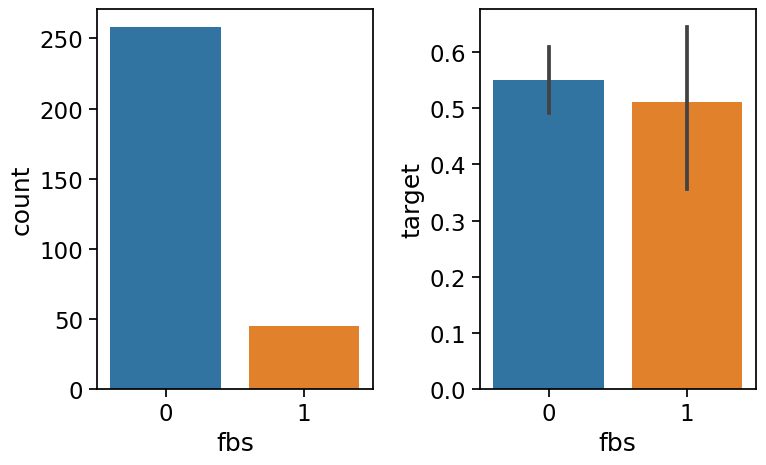

In [26]:
fig, axes = plt.subplots(1, 2)

temp = heart_data.fbs.value_counts()
print(temp)

sns.countplot(data=heart_data, x='fbs', ax=axes[0])
sns.barplot(data=heart_data, x='fbs', y=y, ax=axes[1])

restecg
1    152
0    147
2      4
Name: count, dtype: int64


<Axes: xlabel='restecg', ylabel='target'>

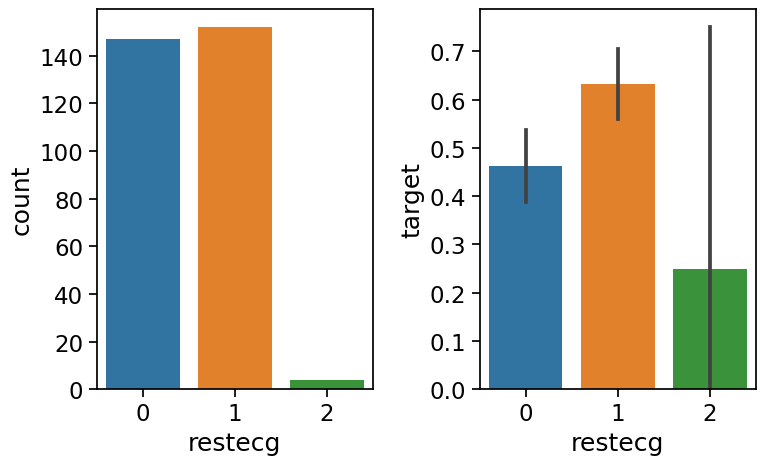

In [27]:
fig, axes = plt.subplots(1, 2)

temp = heart_data.restecg.value_counts()
print(temp)

sns.countplot(data=heart_data, x='restecg', ax=axes[0])
sns.barplot(data=heart_data, x='restecg', y=y, ax=axes[1])

exang
0    204
1     99
Name: count, dtype: int64


<Axes: xlabel='exang', ylabel='target'>

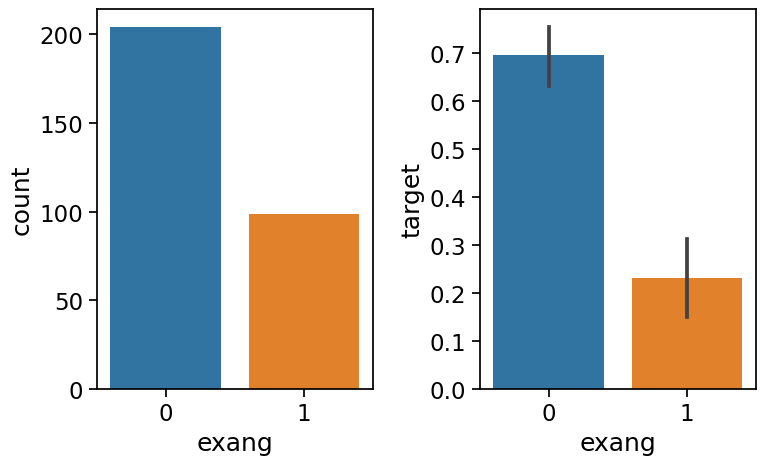

In [28]:
fig, axes = plt.subplots(1, 2)

temp = heart_data.exang.value_counts()
print(temp)

sns.countplot(data=heart_data, x='exang', ax=axes[0])
sns.barplot(data=heart_data, x='exang', y=y, ax=axes[1])

ca
0    175
1     65
2     38
3     20
4      5
Name: count, dtype: int64


<Axes: xlabel='ca', ylabel='target'>

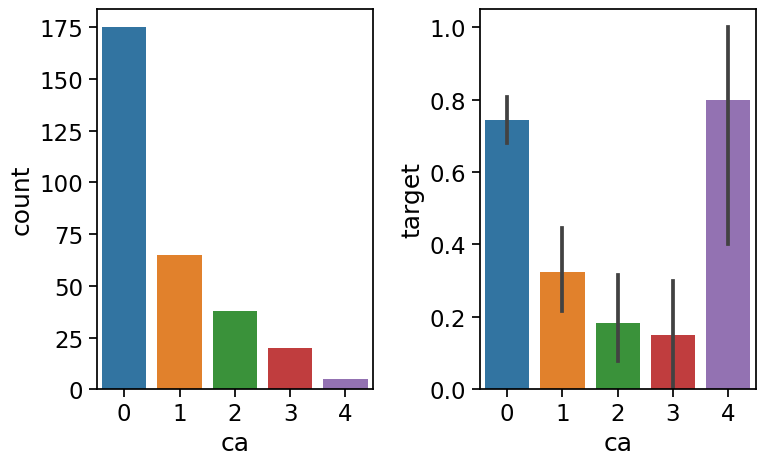

In [29]:
fig, axes = plt.subplots(1, 2)

temp = heart_data.ca.value_counts()
print(temp)

sns.countplot(data=heart_data, x='ca', ax=axes[0])
sns.barplot(data=heart_data, x='ca', y=y, ax=axes[1])

thal
2    166
3    117
1     18
0      2
Name: count, dtype: int64


<Axes: xlabel='thal', ylabel='target'>

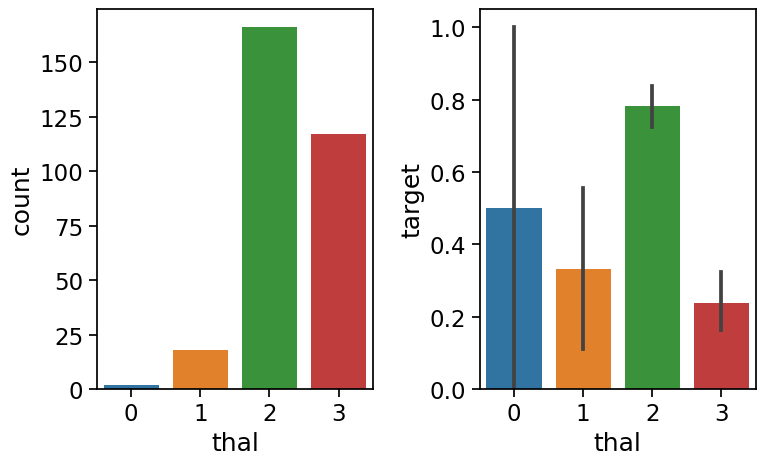

In [30]:
fig, axes = plt.subplots(1, 2)

temp = heart_data.thal.value_counts()
print(temp)

sns.countplot(data=heart_data, x='thal', ax=axes[0])
sns.barplot(data=heart_data, x='thal', y=y, ax=axes[1])

slope
2    142
1    140
0     21
Name: count, dtype: int64


<Axes: xlabel='slope', ylabel='target'>

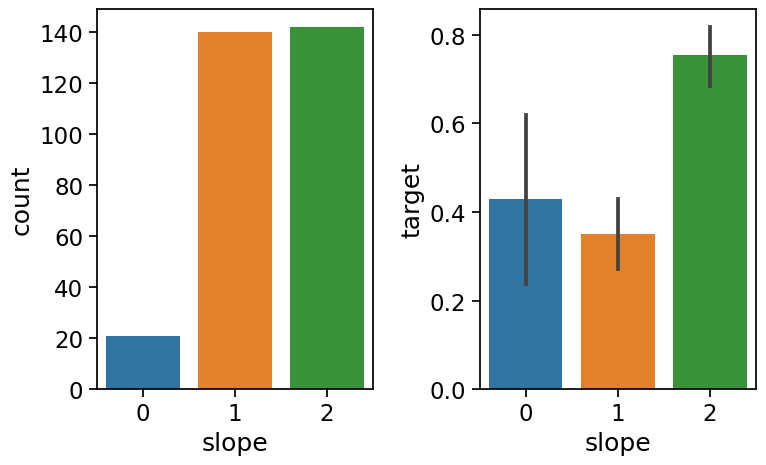

In [31]:
fig, axes = plt.subplots(1, 2)

temp = heart_data.slope.value_counts()
print(temp)

sns.countplot(data=heart_data, x='slope', ax=axes[0])
sns.barplot(data=heart_data, x='slope', y=y, ax=axes[1])

In [32]:
categorical_val = []
continous_val = []
for column in heart_data.columns:
    print("--------------------")
    print(f"{column} : {heart_data[column].unique()}")
    if len(heart_data[column].unique()) <= 10:
        categorical_val.append(column)
    else:
        continous_val.append(column)

--------------------
age : [63 37 41 56 57 44 52 54 48 49 64 58 50 66 43 69 59 42 61 40 71 51 65 53
 46 45 39 47 62 34 35 29 55 60 67 68 74 76 70 38 77]
--------------------
sex : [1 0]
--------------------
cp : [3 2 1 0]
--------------------
trestbps : [145 130 120 140 172 150 110 135 160 105 125 142 155 104 138 128 108 134
 122 115 118 100 124  94 112 102 152 101 132 148 178 129 180 136 126 106
 156 170 146 117 200 165 174 192 144 123 154 114 164]
--------------------
chol : [233 250 204 236 354 192 294 263 199 168 239 275 266 211 283 219 340 226
 247 234 243 302 212 175 417 197 198 177 273 213 304 232 269 360 308 245
 208 264 321 325 235 257 216 256 231 141 252 201 222 260 182 303 265 309
 186 203 183 220 209 258 227 261 221 205 240 318 298 564 277 214 248 255
 207 223 288 160 394 315 246 244 270 195 196 254 126 313 262 215 193 271
 268 267 210 295 306 178 242 180 228 149 278 253 342 157 286 229 284 224
 206 167 230 335 276 353 225 330 290 172 305 188 282 185 326 274 164 307
 249 34

Splitting the Data into Training data & Test Data

In [33]:
X = heart_data.drop("target",axis=1)
Y = heart_data["target"]

X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.20,random_state=5)

print(X.shape, X_train.shape, X_test.shape)

(303, 13) (242, 13) (61, 13)


Logistic Regression Algorithm

In [34]:
LR = LogisticRegression()

In [35]:
LR.fit(X_train, Y_train)

C:\Users\tanma\anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [36]:
Y_pred_LR = LR.predict(X_test)
print(Y_pred_LR.shape)

score_LR = round(accuracy_score(Y_pred_LR,Y_test)*100,2)

print("The accuracy score achieved using Logistic Regression is: "+str(score_LR)+" %")

(61,)
The accuracy score achieved using Logistic Regression is: 91.8 %


Naive Bayes Algorithm

In [37]:
NB = GaussianNB()

In [38]:
NB.fit(X_train,Y_train)

GaussianNB()

In [39]:
Y_pred_NB = NB.predict(X_test)
print(Y_pred_NB.shape)

score_NB = round(accuracy_score(Y_pred_NB,Y_test)*100,2)

print("The accuracy score achieved using Naive Bayes is: "+str(score_NB)+" %")

(61,)
The accuracy score achieved using Naive Bayes is: 86.89 %


Support Vector Machines(SVM)

In [40]:
SVM = SVC(kernel='linear')

In [41]:
SVM.fit(X_train, Y_train)

SVC(kernel='linear')

In [42]:
Y_pred_SVM = SVM.predict(X_test)
print(Y_pred_SVM.shape)

score_SVM = round(accuracy_score(Y_pred_SVM,Y_test)*100,2)

print("The accuracy score achieved using Linear SVM is: "+str(score_SVM)+" %")

(61,)
The accuracy score achieved using Linear SVM is: 90.16 %


K-Nearest Neighbors

In [43]:
KNN = KNeighborsClassifier(n_neighbors=25)

In [44]:
KNN.fit(X_train,Y_train)

KNeighborsClassifier(n_neighbors=25)

In [45]:
Y_pred_KNN=KNN.predict(X_test)
print(Y_pred_KNN.shape)

score_KNN = round(accuracy_score(Y_pred_KNN,Y_test)*100,2)

print("The accuracy score achieved using KNN is: "+str(score_KNN)+" %")

(61,)
The accuracy score achieved using KNN is: 70.49 %


Decision Tree Algorithm

In [46]:
DT = DecisionTreeClassifier(random_state=5)

In [47]:
DT.fit(X_train,Y_train)

DecisionTreeClassifier(random_state=5)

In [48]:
Y_pred_DT = DT.predict(X_test)
print(Y_pred_DT.shape)

score_DT = round(accuracy_score(Y_pred_DT,Y_test)*100,2)

print("The accuracy score achieved using Decision Tree is: "+str(score_DT)+" %")

(61,)
The accuracy score achieved using Decision Tree is: 83.61 %


Random Forest Algorithm

In [49]:
RF = RandomForestClassifier(random_state=5)

In [50]:
RF.fit(X_train,Y_train)

RandomForestClassifier(random_state=5)

In [51]:
Y_pred_RF = RF.predict(X_test)
print(Y_pred_RF.shape)

score_RF = round(accuracy_score(Y_pred_RF,Y_test)*100,2)

print("The accuracy score achieved using Random Forest is: "+str(score_RF)+" %")

(61,)
The accuracy score achieved using Random Forest is: 90.16 %


XGBoost

In [52]:
import xgboost as xgb

XGB = xgb.XGBClassifier(objective="binary:logistic", random_state=5)
XGB.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=5, ...)

In [53]:
Y_pred_XGB = XGB.predict(X_test)
print(Y_pred_XGB.shape)

score_XGB = round(accuracy_score(Y_pred_XGB,Y_test)*100,2)

print("The accuracy score achieved using XGBoost is: "+str(score_XGB)+" %")

(61,)
The accuracy score achieved using XGBoost is: 83.61 %


Output final score

In [54]:
scores = [score_LR,score_NB,score_SVM,score_KNN,score_DT,score_RF,score_XGB]
algorithms = ["Logistic Regression","Naive Bayes","Support Vector Machine","K-Nearest Neighbors","Decision Tree","Random Forest","XGBoost"]    

for i in range(len(algorithms)):
    print("The accuracy score achieved using "+algorithms[i]+" is: "+str(scores[i])+" %")

The accuracy score achieved using Logistic Regression is: 91.8 %
The accuracy score achieved using Naive Bayes is: 86.89 %
The accuracy score achieved using Support Vector Machine is: 90.16 %
The accuracy score achieved using K-Nearest Neighbors is: 70.49 %
The accuracy score achieved using Decision Tree is: 83.61 %
The accuracy score achieved using Random Forest is: 90.16 %
The accuracy score achieved using XGBoost is: 83.61 %


<Axes: xlabel='Algorithms', ylabel='Accuracy score'>

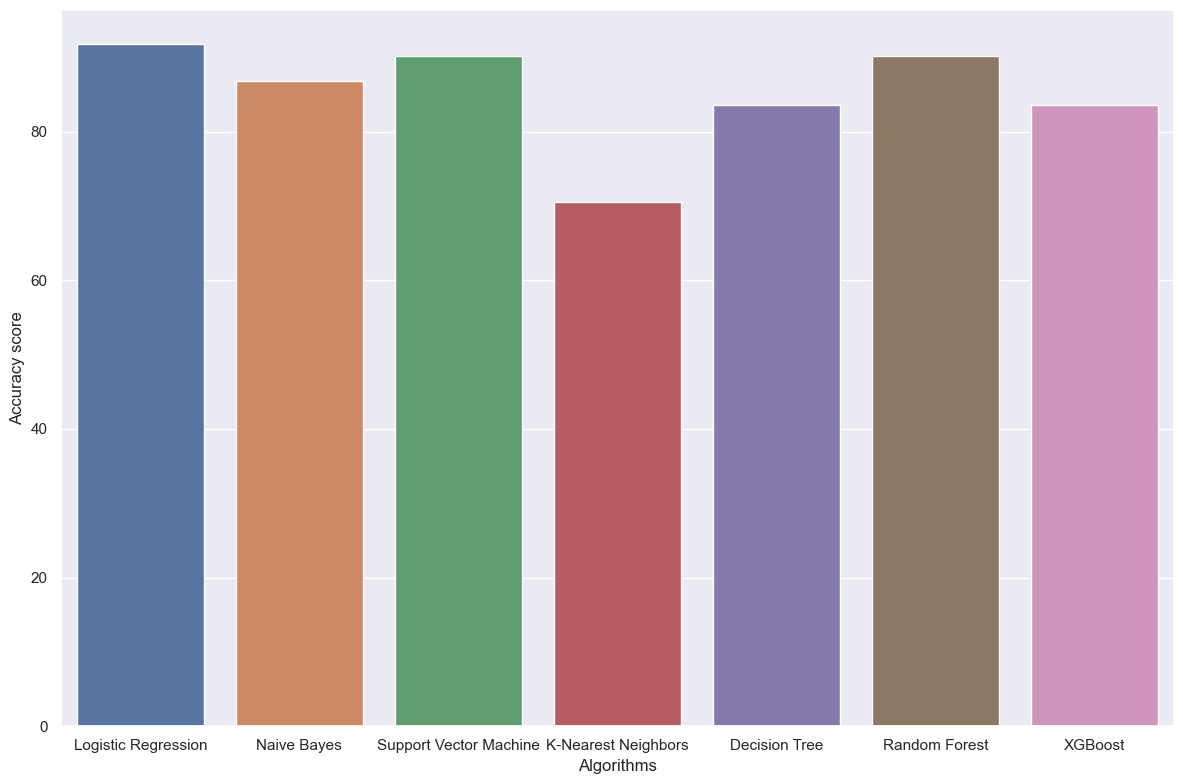

In [55]:

sns.set(rc={'figure.figsize':(12,8)})
plt.xlabel("Algorithms")
plt.ylabel("Accuracy score")

sns.barplot(x=algorithms, y=scores)


Building a Predictive System

In [56]:
input_data = (62,0,0,140,268,0,0,160,0,3.6,0,2,2)

# change the input data to a numpy array
input_data_as_numpy_array= np.asarray(input_data)

# reshape the numpy array as we are predicting for only on instance
input_data_reshaped = input_data_as_numpy_array.reshape(1,-1)

prediction = XGB.predict(input_data_reshaped)
print(prediction)

if (prediction[0]== 0):
  print('The Person does not have a Heart Disease')
else:
  print('The Person has Heart Disease')

[0]
The Person does not have a Heart Disease


In [57]:
import numpy as np

# Assuming 'model' is your trained XGBoost model
def predict_user_input():
    print("Enter age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal:")
    age = float(input("Age: "))
    sex = float(input("Sex (0 for female, 1 for male): "))
    cp = float(input("Chest pain type (cp): "))
    trestbps = float(input("Resting blood pressure (trestbps): "))
    chol = float(input("Serum cholesterol (chol): "))
    fbs = float(input("Fasting blood sugar (fbs): "))
    restecg = float(input("Resting electrocardiographic results (restecg): "))
    thalach = float(input("Maximum heart rate achieved (thalach): "))
    exang = float(input("Exercise induced angina (exang): "))
    oldpeak = float(input("ST depression induced by exercise relative to rest (oldpeak): "))
    slope = float(input("Slope of the peak exercise ST segment (slope): "))
    ca = float(input("Number of major vessels colored by fluoroscopy (ca): "))
    thal = float(input("Thalassemia (thal): "))

    # Create a NumPy array from the user input
    user_data = np.array([[age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal]])

    # Reshape the input data
    user_data_reshaped = user_data.reshape(1, -1)

    # Make predictions
    prediction = XGB.predict(user_data_reshaped)

    # Output the result
    if prediction[0] == 0:
        print('The Person does not have a Heart Disease')
    else:
        print('The Person has Heart Disease')

# Get user input and make predictions
predict_user_input()


Enter age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal:
Age: 24
Sex (0 for female, 1 for male): 0
Chest pain type (cp): 2
Resting blood pressure (trestbps): 34
Serum cholesterol (chol): 43
Fasting blood sugar (fbs): 21
Resting electrocardiographic results (restecg): 3
Maximum heart rate achieved (thalach): 80
Exercise induced angina (exang): 3
ST depression induced by exercise relative to rest (oldpeak): 22
Slope of the peak exercise ST segment (slope): 21
Number of major vessels colored by fluoroscopy (ca): 6
Thalassemia (thal): 4
The Person has Heart Disease


In [58]:
import pickle
 
# Assuming 'model' is the trained model you want to save
with open('model.pkl', 'wb') as file:
    pickle.dump(XGB, file)